<a href="https://colab.research.google.com/github/kaushalkalas-awesome/DKTE-TY-DL/blob/main/DL_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [77]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [78]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Class names
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress',   'Coat',
               'Sandal',  'Shirt',   'Sneaker',  'Bag',     'Ankle Boot']

# Normalize pixel values to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

# CNN expects shape (batch, height, width, channels)
# Fashion-MNIST is grayscale → add channel dimension
X_train = X_train[..., np.newaxis]   # (60000, 28, 28, 1)
X_test  = X_test[...,  np.newaxis]   # (10000, 28, 28, 1)

print(f"Train samples : {X_train.shape[0]}")
print(f"Test samples  : {X_test.shape[0]}")
print(f"Image shape   : {X_train.shape[1:]}")
print(f"Classes       : {class_names}")

Train samples : 60000
Test samples  : 10000
Image shape   : (28, 28, 1)
Classes       : ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']


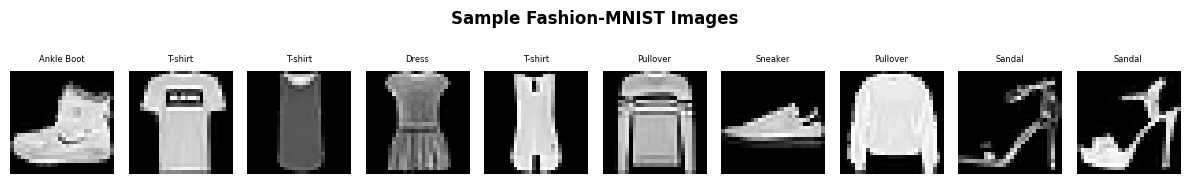

In [79]:
plt.figure(figsize=(12, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(X_train[i].squeeze(), cmap='gray')
    plt.title(class_names[y_train[i]], fontsize=6)
    plt.axis('off')
plt.suptitle('Sample Fashion-MNIST Images', fontweight='bold')
plt.tight_layout()
plt.show()

In [80]:
model = tf.keras.Sequential([

    # Block 1
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu',
                           padding='same',
                           input_shape=(28, 28, 1)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.25),

    # Block 2
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.25),

    # Block 3
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.25),

    # Fully Connected
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu',
                          kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation='softmax')

], name="CNN_Improved")

model.summary()


Model: "CNN_Improved"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 391,306 (1.49 MB)

 Trainable params: 390,858 (1.49 MB)

 Non-trainable params: 448 (1.75 KB)

In [81]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [82]:
print("\nTraining CNN...")
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)


Training CNN...
Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.7744 - loss: 0.9791 - val_accuracy: 0.8516 - val_loss: 0.6547
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8505 - loss: 0.6011 - val_accuracy: 0.8828 - val_loss: 0.4774
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8708 - loss: 0.4927 - val_accuracy: 0.8917 - val_loss: 0.4306
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8825 - loss: 0.4409 - val_accuracy: 0.8935 - val_loss: 0.3953
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8878 - loss: 0.4195 - val_accuracy: 0.9058 - val_loss: 0.3730
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8939 - loss: 0.4082 - val_accuracy: 0.9106 - val_loss: 0.3594
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8975 - loss: 0.4007 - val_accuracy: 0.9112 - val_loss: 0.3541
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8997 - loss: 0.3884 

In [83]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Loss     : {loss:.4f}")
print(f"Test Accuracy : {acc*100:.2f}%")


Test Loss     : 0.4186
Test Accuracy : 89.42%


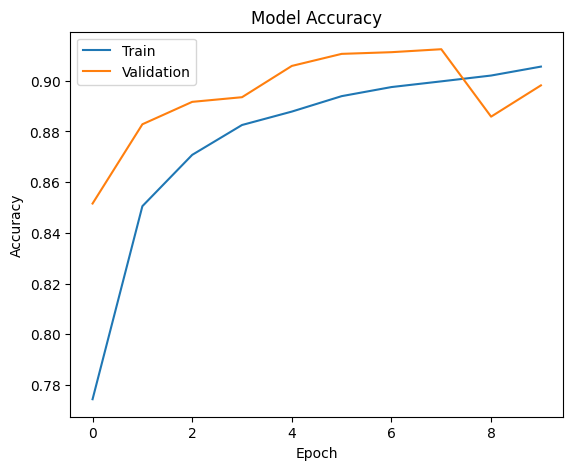

In [84]:
plt.figure(figsize=(14, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

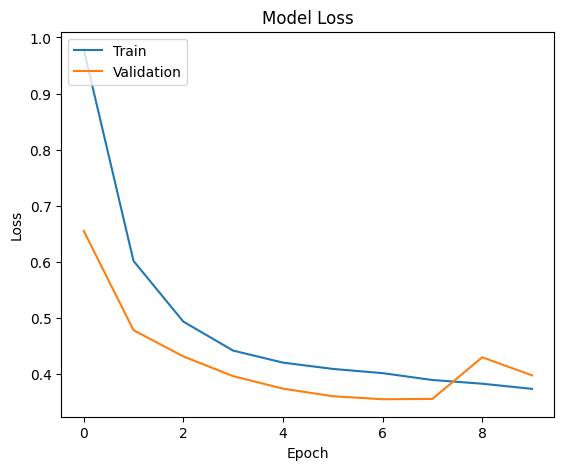

In [85]:
plt.figure(figsize=(14, 5))

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

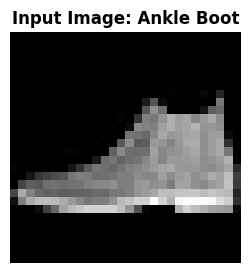

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
Feature Map Shape : (1, 28, 28, 32)


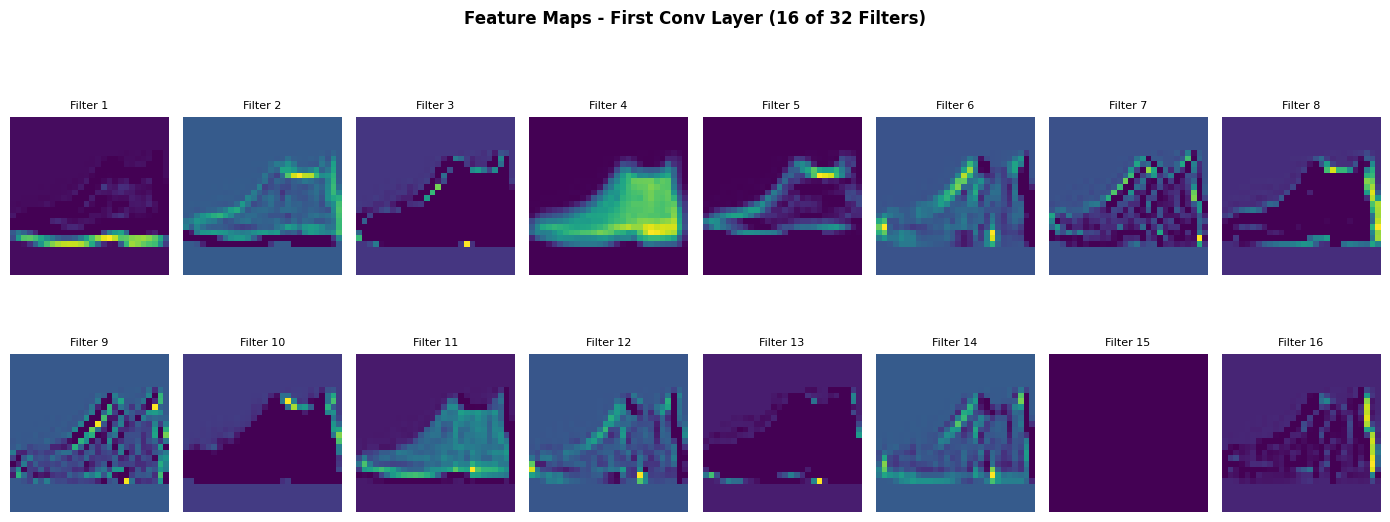

In [86]:
# Pick one test image
sample_image = X_test[0:1]          # Shape: (1, 28, 28, 1)
true_label   = class_names[y_test[0]]

# Show original image
plt.figure(figsize=(3, 3))
plt.imshow(X_test[0].squeeze(), cmap='gray')
plt.title(f'Input Image: {true_label}', fontweight='bold')
plt.axis('off')
plt.show()

# Feature map model \u2192 output of first Conv layer
# Fix: Explicitly create an Input layer and trace it through the first layer
input_shape = model.input_shape[1:] # Get input shape from the trained model
input_tensor = tf.keras.Input(shape=input_shape)
x = model.layers[0](input_tensor) # Pass input through the first Conv2D layer

feature_map_model = tf.keras.Model(
    inputs=input_tensor,
    outputs=x
)

# Get feature maps
feature_maps = feature_map_model.predict(sample_image)
print(f"Feature Map Shape : {feature_maps.shape}")
# (1, 28, 28, 32) \u2192 32 filters

# Plot first 16 feature maps
plt.figure(figsize=(14, 6))
for i in range(16):
    plt.subplot(2, 8, i + 1)
    plt.imshow(feature_maps[0, :, :, i], cmap='viridis')
    plt.title(f'Filter {i+1}', fontsize=8)
    plt.axis('off')
plt.suptitle('Feature Maps - First Conv Layer (16 of 32 Filters)',
             fontweight='bold')
plt.tight_layout()
plt.show()